# High-Dimensional Clustering with 2D UMAP Visualization

In [1]:
import hyrax
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import logging
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering, OPTICS, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
def extract_umap_info(x,y,base_directory="/mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs"):
  """Extract UMAP directory and inference directory from 3dumap output file and TOML config."""
  import re
  import toml
  
  # Construct paths
  run_dir = Path(base_directory) / f"run{x}"
  dumap_name = f"udb{x}_{y}"

  dumap_output_file = run_dir / f"{dumap_name}.txt"
  dumap_toml_file = run_dir / f"{dumap_name}.toml"
    
  try:
      # Extract UMAP directory from output file
      with open(dumap_output_file, 'r') as f:
          content = f.read()

      # Look for the UMAP results save pattern
      pattern = r'Saving UMAP results to (.+)'
      match = re.search(pattern, content)

      if not match:
          raise ValueError(f"Could not find UMAP directory in {dumap_output_file}")
      
      umap_dir = match.group(1).strip()
      
      # Extract inference directory from TOML file
      with open(dumap_toml_file, 'r') as f:
          config = toml.load(f)
      
      # The inference directory should be in [results][inference_dir]
      if 'results' not in config:
          raise ValueError(f"No [results] section found in {dumap_toml_file}")
      
      if 'inference_dir' not in config['results']:
          raise ValueError(f"No inference_dir found in [results] section of {dumap_toml_file}")
      
      inference_dir = config['results']['inference_dir']
      
      return umap_dir, inference_dir, dumap_toml_file

  except FileNotFoundError as e:
      if 'output' in str(e):
          raise FileNotFoundError(f"3dumap output file not found: {dumap_output_file}")
      else:
          raise FileNotFoundError(f"3dumap TOML file not found: {dumap_toml_file}")
  except Exception as e:
      raise RuntimeError(f"Error extracting info: {e}")

In [3]:
def plot_highdim_clusters_on_umap(ax, config=None, inference_dir=None, umap_dir=None,
                                  clustering_method='kmeans', n_clusters=8,
                                  clustering_params=None, 
                                  alpha=0.6, s=5, cmap='tab10',
                                  show_cluster_centers=False, show_metrics=True,
                                  title=None, supress_hyrax_logs=False):
    """
    Perform clustering in high-dimensional latent space and visualize in 2D UMAP space.
    
    This function clusters data in the original high-dimensional latent space (from inference)
    but visualizes the cluster assignments overlaid on the 2D UMAP representation.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot on
    config: 
        Hyrax config object
    inference_dir : str or Path, required
        Directory containing original inference results (high-dimensional data)
    umap_dir : str or Path, required  
        Directory containing UMAP results (2D coordinates for visualization)
    clustering_method : str, default 'kmeans'
        Clustering algorithm to use
    n_clusters : int, default 8
        Number of clusters for algorithms that require it
    clustering_params : dict, optional
        Additional parameters to pass to clustering algorithm
    alpha : float, default 0.6
        Point transparency
    s : float, default 5
        Point size
    cmap : str, default 'tab10'
        Colormap name (discrete colormap recommended for clusters)
    show_cluster_centers : bool, default False
        Whether to show cluster centers projected to 2D UMAP space
    show_metrics : bool, default True
        Whether to display clustering metrics in title
    title : str, optional
        Custom plot title
    supress_hyrax_logs : bool, default False
        Whether to suppress hyrax logging output
        
    Returns
    -------
    dict
        Dictionary containing:
        - 'ax': The matplotlib axis object
        - 'labels': Cluster labels for each point
        - 'centers_highdim': Cluster centers in high-dimensional space
        - 'centers_2d': Cluster centers projected to 2D UMAP space (if applicable)
        - 'metrics': Dictionary of clustering metrics
    """
    
    from hyrax.data_sets.inference_dataset import InferenceDataSet
    
    # Check required parameters
    if inference_dir is None:
        raise ValueError("inference_dir parameter is required")
    if umap_dir is None:
        raise ValueError("umap_dir parameter is required")
    
    if supress_hyrax_logs:
        logging.disable(logging.CRITICAL)
    
    # Load high-dimensional inference results (original latent space)
    inference_results = InferenceDataSet(config, results_dir=inference_dir)
    
    # Load 2D UMAP results for visualization
    umap_results = InferenceDataSet(config, results_dir=umap_dir, verb="umap")
    
    logging.disable(logging.NOTSET)
    
    # Extract high-dimensional data for clustering (flatten like in umap.py)
    highdim_points = np.array([point.numpy() for point in inference_results])
    # Flatten all dimensions except the first (sample) dimension
    highdim_data = highdim_points.reshape(highdim_points.shape[0], -1)
    
    # Extract 2D coordinates for visualization  
    umap_points = np.array([point.numpy() for point in umap_results])
    x, y = umap_points[:, 0], umap_points[:, 1]
    
    # Verify data alignment
    if len(highdim_data) != len(umap_points):
        raise ValueError(f"Mismatch in data lengths: {len(highdim_data)} high-dim vs {len(umap_points)} UMAP points")
    
    # Set up clustering parameters
    if clustering_params is None:
        clustering_params = {}
    
    # Perform clustering in high-dimensional space
    cluster_labels, cluster_centers_highdim, metrics = apply_clustering(
        highdim_data, clustering_method, n_clusters, **clustering_params
    )
    
    # Project cluster centers to 2D UMAP space if centers exist
    cluster_centers_2d = None
    if cluster_centers_highdim is not None:
        # For each cluster center, find the closest point in high-dim space
        # and use its corresponding UMAP coordinates
        from sklearn.metrics.pairwise import euclidean_distances
        
        cluster_centers_2d = []
        for center in cluster_centers_highdim:
            # Find closest point in high-dimensional space
            distances = euclidean_distances([center], highdim_data)[0]
            closest_idx = np.argmin(distances)
            # Use corresponding 2D UMAP coordinates
            center_2d = umap_points[closest_idx]
            cluster_centers_2d.append(center_2d)
        cluster_centers_2d = np.array(cluster_centers_2d)
    
    # Create scatter plot colored by cluster (using 2D UMAP coordinates)
    scatter = ax.scatter(x, y, c=cluster_labels, alpha=alpha, s=s, cmap=cmap)
    
    # Add cluster centers if requested and available
    if show_cluster_centers and cluster_centers_2d is not None:
        ax.scatter(cluster_centers_2d[:, 0], cluster_centers_2d[:, 1], 
                  c='red', marker='x', s=100, linewidths=3, label='Centers (projected)')
        ax.legend()
    
    # Add colorbar for cluster labels
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Cluster')
    
    # Set title with metrics if requested
    if title is None:
        title_parts = [f'{clustering_method.upper()} (High-Dim)']
        if show_metrics and metrics:
            if 'silhouette_score' in metrics:
                title_parts.append(f"Silhouette: {metrics['silhouette_score']:.3f}")
            if 'n_clusters' in metrics:
                title_parts.append(f"Clusters: {metrics['n_clusters']}")
        title = ' | '.join(title_parts)
    
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    return {
        'ax': ax,
        'labels': cluster_labels,
        'centers_highdim': cluster_centers_highdim,
        'centers_2d': cluster_centers_2d,
        'metrics': metrics
    }

## Different Clustering Functions 

In [4]:
def apply_kmeans_clustering(data, n_clusters=8, **params):
    """
    Apply KMeans clustering to 2D UMAP data.
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    n_clusters : int, default 8
        Number of clusters
    **params : dict
        Additional parameters for KMeans
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    # Set default parameters for KMeans
    kmeans_params = {
        'n_clusters': n_clusters,
        'random_state': 42,
        'n_init': 10
    }
    kmeans_params.update(params)
    
    clusterer = KMeans(**kmeans_params)
    cluster_labels = clusterer.fit_predict(data)
    cluster_centers = clusterer.cluster_centers_
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found,
        'inertia': clusterer.inertia_
    }
    
    return cluster_labels, cluster_centers, metrics

In [5]:
def apply_dbscan_clustering(data, eps=0.5, min_samples=5, **params):
    """
    Apply DBSCAN clustering to 2D UMAP data.
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    eps : float, default 0.5
        Maximum distance between samples for them to be considered neighbors
    min_samples : int, default 5
        Minimum number of samples in a neighborhood for a point to be core
    **params : dict
        Additional parameters for DBSCAN
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    # Set default parameters for DBSCAN
    dbscan_params = {
        'eps': eps,
        'min_samples': min_samples
    }
    dbscan_params.update(params)
    
    clusterer = DBSCAN(**dbscan_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers for each cluster (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]  # Exclude noise points (-1)
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            # Calculate coordinate-wise median
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    # Calculate silhouette score only if we have more than 1 cluster
    if n_clusters_found > 1:
        # Exclude noise points for silhouette calculation
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(
                data[non_noise_mask], 
                cluster_labels[non_noise_mask]
            )
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

In [6]:
def apply_hdbscan_clustering(data, min_cluster_size=5, min_samples=None, **params):
    """Apply HDBSCAN clustering to 2D UMAP data."""
    hdbscan_params = {
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples
    }
    hdbscan_params.update(params)
    
    clusterer = HDBSCAN(**hdbscan_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    if n_clusters_found > 1:
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(data[non_noise_mask], cluster_labels[non_noise_mask])
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

In [7]:
def apply_gmm_clustering(data, n_components=8, **params):
    """Apply Gaussian Mixture Model clustering to 2D UMAP data."""
    gmm_params = {
        'n_components': n_components,
        'random_state': 42
    }
    gmm_params.update(params)
    
    clusterer = GaussianMixture(**gmm_params)
    clusterer.fit(data)
    cluster_labels = clusterer.predict(data)
    cluster_centers = clusterer.means_  # GMM has explicit means
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found,
        'aic': clusterer.aic(data),
        'bic': clusterer.bic(data)
    }
    
    return cluster_labels, cluster_centers, metrics

In [8]:
def apply_spectral_clustering(data, n_clusters=8, **params):
    """Apply Spectral clustering to 2D UMAP data."""
    spectral_params = {
        'n_clusters': n_clusters,
        'random_state': 42
    }
    spectral_params.update(params)
    
    clusterer = SpectralClustering(**spectral_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers
    cluster_centers = []
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        if np.any(cluster_mask):
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
    cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found
    }
    
    return cluster_labels, cluster_centers, metrics

In [9]:
def apply_agglomerative_clustering(data, n_clusters=8, **params):
    """Apply Agglomerative clustering to 2D UMAP data."""
    agg_params = {
        'n_clusters': n_clusters,
        'linkage': 'ward'
    }
    agg_params.update(params)
    
    clusterer = AgglomerativeClustering(**agg_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers
    cluster_centers = []
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        if np.any(cluster_mask):
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
    cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(data, cluster_labels)
    unique_labels = np.unique(cluster_labels)
    n_clusters_found = len(unique_labels)
    
    metrics = {
        'silhouette_score': silhouette_avg,
        'n_clusters': n_clusters_found
    }
    
    return cluster_labels, cluster_centers, metrics

In [10]:
def apply_optics_clustering(data, min_samples=5, xi=0.05, **params):
    """Apply OPTICS clustering to 2D UMAP data."""
    optics_params = {
        'min_samples': min_samples,
        'xi': xi,
        'cluster_method': 'xi'
    }
    optics_params.update(params)
    
    clusterer = OPTICS(**optics_params)
    cluster_labels = clusterer.fit_predict(data)
    
    # Calculate coordinate-wise median centers (excluding noise)
    unique_labels = np.unique(cluster_labels)
    valid_clusters = unique_labels[unique_labels != -1]
    
    cluster_centers = None
    if len(valid_clusters) > 0:
        cluster_centers = []
        for cluster_id in valid_clusters:
            cluster_mask = cluster_labels == cluster_id
            cluster_points = data[cluster_mask]
            center = np.median(cluster_points, axis=0)
            cluster_centers.append(center)
        cluster_centers = np.array(cluster_centers)
    
    # Calculate metrics
    n_clusters_found = len(valid_clusters)
    n_noise = np.sum(cluster_labels == -1)
    
    metrics = {
        'n_clusters': n_clusters_found,
        'n_noise_points': n_noise,
        'noise_fraction': n_noise / len(cluster_labels)
    }
    
    if n_clusters_found > 1:
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            silhouette_avg = silhouette_score(data[non_noise_mask], cluster_labels[non_noise_mask])
            metrics['silhouette_score'] = silhouette_avg
    
    return cluster_labels, cluster_centers, metrics

#### Clustering Dispatcher Function

In [11]:
def apply_clustering(data, method='kmeans', n_clusters=8, **params):
    """
    Apply clustering algorithm to 2D UMAP data (dispatcher function).
    
    Parameters
    ----------
    data : np.ndarray
        2D array of UMAP coordinates (n_samples, 2)
    method : str, default 'kmeans'
        Clustering method: 'kmeans', 'dbscan', 'hdbscan', 'gmm', 'spectral', 'agglomerative', 'optics'
    n_clusters : int, default 8
        Number of clusters for methods that require it (ignored for density-based methods)
    **params : dict
        Additional parameters for clustering algorithm
        
    Returns
    -------
    tuple
        (cluster_labels, cluster_centers, metrics)
    """
    
    if method == 'kmeans':
        return apply_kmeans_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'dbscan':
        return apply_dbscan_clustering(data, **params)
    elif method == 'hdbscan':
        return apply_hdbscan_clustering(data, **params)
    elif method == 'gmm':
        return apply_gmm_clustering(data, n_components=n_clusters, **params)
    elif method == 'spectral':
        return apply_spectral_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'agglomerative':
        return apply_agglomerative_clustering(data, n_clusters=n_clusters, **params)
    elif method == 'optics':
        return apply_optics_clustering(data, **params)
    else:
        supported_methods = ['kmeans', 'dbscan', 'hdbscan', 'gmm', 'spectral', 'agglomerative', 'optics']
        raise ValueError(f"Unsupported clustering method: {method}. Supported methods: {supported_methods}")

## Example of Different Clustering Methods

![Different Clustering Methods](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

## run4 - High-Dimensional Clustering

[2025-08-02 00:40:34,734 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.
[2025-08-02 00:40:34,735 hyrax.config_utils:WARNING] Cannot find default_config.toml for torch.
[2025-08-02 00:40:34,735 hyrax.config_utils:WARNING] Cannot find default_config.toml for umap.
[2025-08-02 00:40:34,741 hyrax:INFO] Runtime Config read from: /mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs/run4/udb4_12.toml


Using inference directory: /mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs/results/20250716-165453-infer-qHSh/
Using UMAP directory: /mmfs1/gscratch/dirac/aritrag/hyrax_comcam_dp1_runs/results/20250717-161521-umap-DmtD


Running high-dim clustering methods:   0%|          | 0/5 [00:00<?, ?it/s]

Running KMEANS clustering in high-dimensional space...
Running DBSCAN clustering in high-dimensional space...
Running HDBSCAN clustering in high-dimensional space...
Running OPTICS clustering in high-dimensional space...


/mmfs1/gscratch/dirac/aritrag/miniconda3/envs/hyrax/lib/python3.10/site-packages/sklearn/cluster/_optics.py:664: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(


Running SPECTRAL clustering in high-dimensional space...


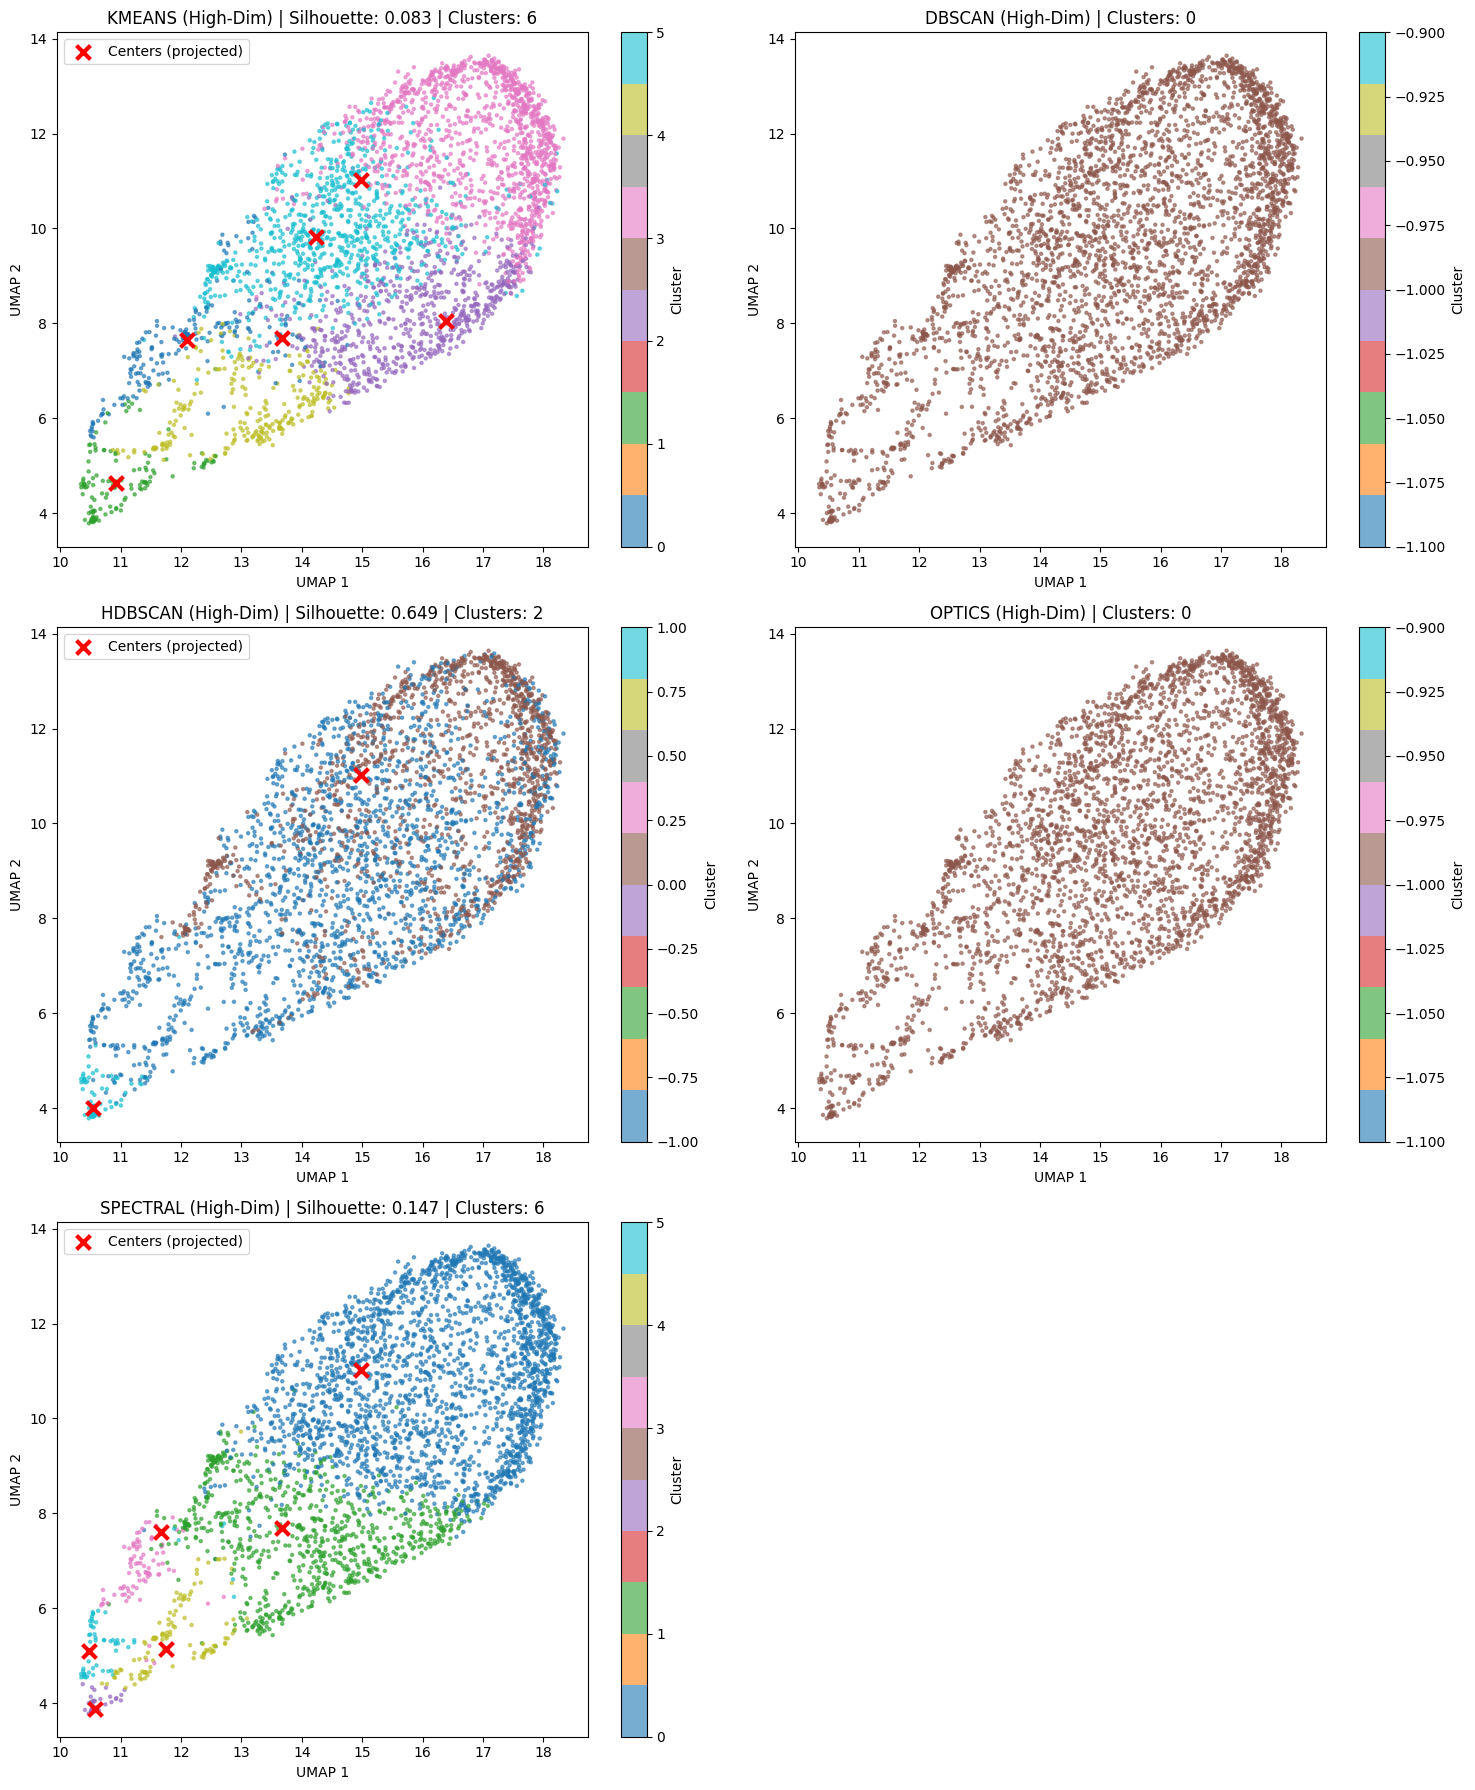

In [13]:
# Test with run 4, experiment 12 data - High-Dimensional Clustering with 2D UMAP Visualization
from tqdm.notebook import tqdm

run = 4
expt = 12

# Get UMAP info, inference directory, and create hyrax config
umap_dir, inference_dir, config_file = extract_umap_info(run, expt)
h = hyrax.Hyrax(config_file=config_file)

print(f"Using inference directory: {inference_dir}")
print(f"Using UMAP directory: {umap_dir}")

# Create subplot grid (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

# Define clustering methods and their parameters
# Note: For high-dimensional clustering, we may want to adjust parameters
# as the data characteristics can be quite different
clustering_configs = [
    ('kmeans', 6, {}, True),  
    ('dbscan', None, {'eps': 2.0, 'min_samples': 10}, True),  # Larger eps for high-dim
    ('hdbscan', None, {'min_cluster_size': 15}, True),
    ('optics', None, {'min_samples': 10, 'xi': 0.05, 'max_eps': 5.0}, True),  # Larger max_eps
    ('spectral', 6, {'affinity': 'nearest_neighbors', 'n_neighbors': 15}, True)
]

results = {}

# Plot each clustering method
for i, (method, n_clusters, params, show_centers) in enumerate(tqdm(clustering_configs, desc="Running high-dim clustering methods")):
    if i < len(axes):
        print(f"Running {method.upper()} clustering in high-dimensional space...")
        
        try:
            result = plot_highdim_clusters_on_umap(
                axes[i], 
                config=h.config, 
                inference_dir=inference_dir,
                umap_dir=umap_dir,
                clustering_method=method,
                n_clusters=n_clusters if n_clusters is not None else 8,
                clustering_params=params,
                show_cluster_centers=show_centers,
                supress_hyrax_logs=True
            )
            
            results[method] = result
            
        except Exception as e:
            print(f"Error with {method}: {e}")
            axes[i].text(0.5, 0.5, f"Error: {method}\n{str(e)}", 
                        transform=axes[i].transAxes, ha='center', va='center')
            axes[i].set_title(f"{method.upper()} - Error")

# Hide the last unused subplot
if len(clustering_configs) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# Print summary of all high-dimensional clustering results
print("\n" + "="*60)
print("HIGH-DIMENSIONAL CLUSTERING COMPARISON SUMMARY")
print("(Clustering performed in high-dim space, visualized in 2D UMAP)")
print("="*60)

for method, result in results.items():
    print(f"\n{method.upper()}:")
    print(f"  Clusters: {result['metrics']['n_clusters']}")
    
    if 'silhouette_score' in result['metrics']:
        print(f"  Silhouette Score (high-dim): {result['metrics']['silhouette_score']:.3f}")
    
    if 'n_noise_points' in result['metrics']:
        print(f"  Noise Points: {result['metrics']['n_noise_points']}")
        print(f"  Noise Fraction: {result['metrics']['noise_fraction']:.3f}")
    
    if 'inertia' in result['metrics']:
        print(f"  Inertia (high-dim): {result['metrics']['inertia']:.1f}")
    
    if 'aic' in result['metrics']:
        print(f"  AIC: {result['metrics']['aic']:.1f}")
        print(f"  BIC: {result['metrics']['bic']:.1f}")

print("\n" + "="*60)
print("NOTES:")
print("- Clustering is performed in the original high-dimensional latent space")
print("- Cluster assignments are then visualized in the 2D UMAP embedding")
print("- Silhouette scores are calculated in high-dimensional space")
print("- Cluster centers are projected to 2D for visualization")
print("="*60)


HIGH-DIMENSIONAL CLUSTERING COMPARISON SUMMARY
(Clustering performed in high-dim space, visualized in 2D UMAP)

KMEANS:
  Clusters: 6
  Silhouette Score (high-dim): 0.083
  Inertia (high-dim): 4600631.4

DBSCAN:
  Clusters: 0
  Noise Points: 3391
  Noise Fraction: 1.000

HDBSCAN:
  Clusters: 2
  Silhouette Score (high-dim): 0.649
  Noise Points: 1911
  Noise Fraction: 0.564

OPTICS:
  Clusters: 0
  Noise Points: 3391
  Noise Fraction: 1.000

SPECTRAL:
  Clusters: 6
  Silhouette Score (high-dim): 0.147

NOTES:
- Clustering is performed in the original high-dimensional latent space
- Cluster assignments are then visualized in the 2D UMAP embedding
- Silhouette scores are calculated in high-dimensional space
- Cluster centers are projected to 2D for visualization


[2025-08-02 00:42:27,816 hyrax.data_sets.lsst_dataset:INFO] Did not detect a Butler. You may need to run on the RSP
[2025-08-02 00:42:27,838 hyrax.data_sets.downloaded_lsst_dataset:INFO] Found existing manifest at /mmfs1/gscratch/scrubbed/aritrag/comcam_dp1/ecdfs_objects_public_dp1_34asec/manifest.fits


Comparing K-Means clustering: 2D UMAP vs High-Dimensional


[2025-08-02 00:42:28,219 hyrax.data_sets.downloaded_lsst_dataset:INFO] Requested bands ['g', 'i', 'r', 'z'] are a subset of available ['g', 'i', 'r', 'u', 'y', 'z']
[2025-08-02 00:42:28,219 hyrax.data_sets.downloaded_lsst_dataset:INFO] Band filtering setup: ['u', 'g', 'r', 'i', 'z', 'y'] -> ['g', 'r', 'i', 'z']
[2025-08-02 00:42:28,220 hyrax.data_sets.downloaded_lsst_dataset:INFO] Tensor indices to extract: [1, 2, 3, 4]
[2025-08-02 00:42:28,404 hyrax.data_sets.downloaded_lsst_dataset:INFO] Current catalog (3391 objects)                            is a subset of existing manifest (494820 objects). Using existing manifest                            with filtering for operations.
[2025-08-02 00:42:29,143 hyrax.data_sets.downloaded_lsst_dataset:INFO] Manifest merge completed: 494820 preserved, 0 added


2D UMAP clustering silhouette score: 0.381
High-dim clustering silhouette score: 0.083
Difference: -0.298


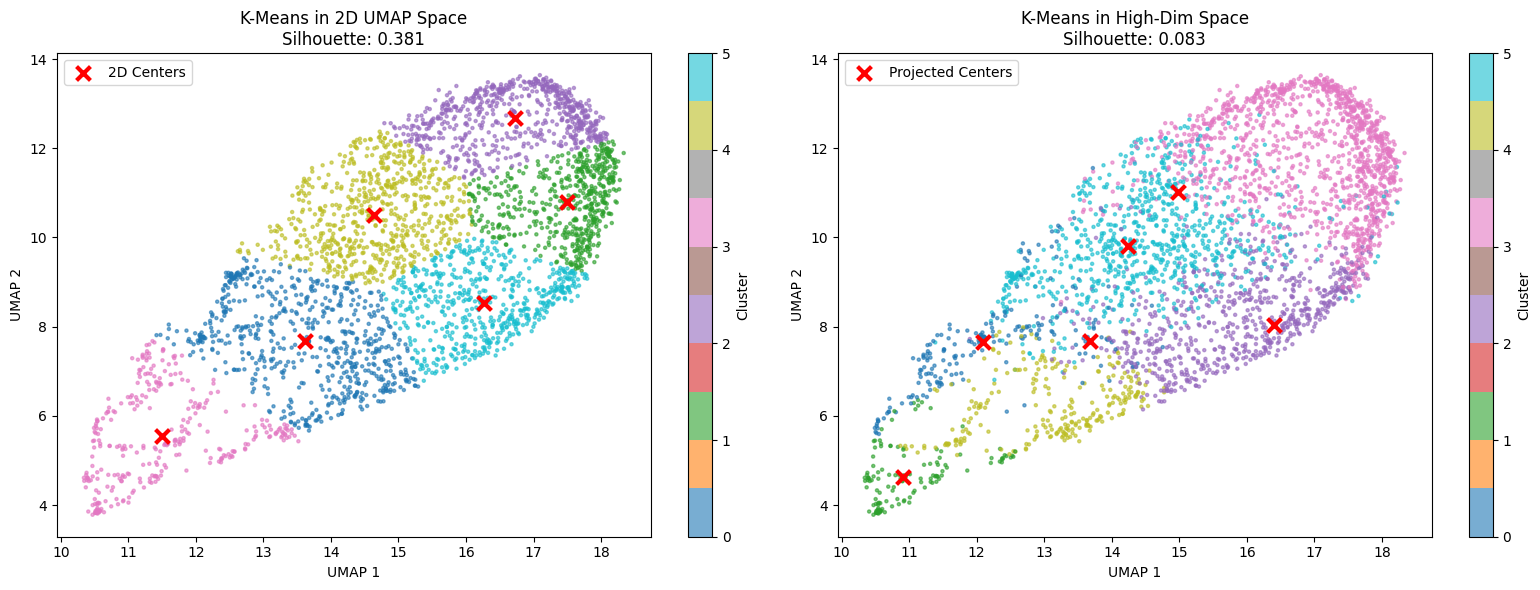


Key Differences:
- Left: Clustering performed in 2D UMAP space
- Right: Clustering performed in original high-dimensional latent space, visualized in 2D
- High-dimensional clustering may capture more subtle patterns lost in UMAP projection
- 2D clustering may be more visually intuitive but potentially less meaningful


In [15]:
# Comparison: 2D UMAP clustering vs High-Dimensional clustering
# This cell demonstrates the difference between clustering in 2D UMAP space vs high-dimensional space

# Create a side-by-side comparison for K-means
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

print("Comparing K-Means clustering: 2D UMAP vs High-Dimensional")

# 2D UMAP clustering (original method)
try:
    from hyrax.data_sets.inference_dataset import InferenceDataSet
    
    umap_results_2d = InferenceDataSet(h.config, results_dir=umap_dir, verb="umap")
    umap_points_2d = np.array([point.numpy() for point in umap_results_2d])
    
    # Cluster in 2D UMAP space
    cluster_labels_2d, cluster_centers_2d, metrics_2d = apply_clustering(
        umap_points_2d, 'kmeans', n_clusters=6
    )
    
    # Plot 2D clustering
    scatter1 = ax1.scatter(umap_points_2d[:, 0], umap_points_2d[:, 1], 
                          c=cluster_labels_2d, alpha=0.6, s=5, cmap='tab10')
    if cluster_centers_2d is not None:
        ax1.scatter(cluster_centers_2d[:, 0], cluster_centers_2d[:, 1], 
                   c='red', marker='x', s=100, linewidths=3, label='2D Centers')
    
    ax1.set_title(f'K-Means in 2D UMAP Space\nSilhouette: {metrics_2d["silhouette_score"]:.3f}')
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.legend()
    plt.colorbar(scatter1, ax=ax1, label='Cluster')

    # High-dimensional clustering (from previous results)
    if 'kmeans' in results:
        highdim_result = results['kmeans']
        scatter2 = ax2.scatter(umap_points_2d[:, 0], umap_points_2d[:, 1], 
                              c=highdim_result['labels'], alpha=0.6, s=5, cmap='tab10')
        if highdim_result['centers_2d'] is not None:
            ax2.scatter(highdim_result['centers_2d'][:, 0], highdim_result['centers_2d'][:, 1], 
                       c='red', marker='x', s=100, linewidths=3, label='Projected Centers')
        
        silhouette_highdim = highdim_result['metrics']['silhouette_score']
        ax2.set_title(f'K-Means in High-Dim Space\nSilhouette: {silhouette_highdim:.3f}')
        ax2.set_xlabel('UMAP 1')
        ax2.set_ylabel('UMAP 2')
        ax2.legend()
        plt.colorbar(scatter2, ax=ax2, label='Cluster')
        
        print(f"2D UMAP clustering silhouette score: {metrics_2d['silhouette_score']:.3f}")
        print(f"High-dim clustering silhouette score: {silhouette_highdim:.3f}")
        print(f"Difference: {silhouette_highdim - metrics_2d['silhouette_score']:.3f}")
    else:
        ax2.text(0.5, 0.5, 'High-dim K-means\nresults not available', 
                transform=ax2.transAxes, ha='center', va='center')
        ax2.set_title('High-Dim K-Means - Not Available')

except Exception as e:
    print(f"Error in comparison: {e}")
    ax1.text(0.5, 0.5, f'Error: {str(e)}', transform=ax1.transAxes, ha='center', va='center')
    ax2.text(0.5, 0.5, f'Error: {str(e)}', transform=ax2.transAxes, ha='center', va='center')

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("- Left: Clustering performed in 2D UMAP space")
print("- Right: Clustering performed in original high-dimensional latent space, visualized in 2D")
print("- High-dimensional clustering may capture more subtle patterns lost in UMAP projection")
print("- 2D clustering may be more visually intuitive but potentially less meaningful")